# Columna vertical bajo su propio peso: problema no lineal resuelto con `fsolve`

En este notebook se estudia una **columna vertical empotrada en la base y libre en el extremo superior** que se dobla por efecto de su **propio peso**.

A diferencia de una versión simplificada, aquí **no** se usa la aproximación lineal $\sin\theta \approx \theta$.  
Se resolverá directamente el problema **no lineal** usando `fsolve` de `scipy.optimize`.

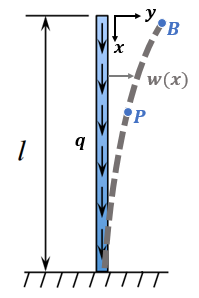
## 1. Modelo diferencial no lineal

Sea $x$ la coordenada medida desde la base hasta la punta, con $0 \le x \le L$.

Si $w=\rho A g$ es el peso por unidad de longitud, la fuerza axial interna en una sección ubicada en $x$ es

$P(x)=w(L-x)$

porque esa sección soporta el peso del tramo que está por encima.

Si $\theta(x)$ es el ángulo local de la columna respecto a la vertical, la ecuación no lineal de equilibrio es

$EI \dfrac{d^2\theta}{dx^2} + P(x)\sin\theta = 0$

es decir,

$EI \dfrac{d^2\theta}{dx^2} + w(L-x)\sin\theta = 0$

## 2. Forma adimensional

Definimos la variable adimensional

$\xi = \dfrac{x}{L}$

y el parámetro

$\lambda = \dfrac{wL^3}{EI}$

Entonces el problema se escribe como

$\dfrac{d^2\theta}{d\xi^2} + \lambda(1-\xi)\sin\theta = 0$

## 3. Condiciones de frontera

Se impondrán las condiciones

$\theta(0)=0$

$\dfrac{d\theta}{d\xi}(1)=1$

La primera representa el **empotramiento** en la base.  
La segunda fija la escala de la solución en la punta, para evitar la solución trivial $\theta=0$.

## 4. Discretización por diferencias finitas

Dividimos el intervalo $[0,1]$ en $N$ subintervalos de tamaño

$h=\dfrac{1}{N}$

con nodos $\xi_i=ih$.

Para la segunda derivada se usa la fórmula centrada

$\dfrac{d^2\theta}{d\xi^2}\bigg|_{\xi_i} \approx \dfrac{\theta_{i-1}-2\theta_i+\theta_{i+1}}{h^2}$

De esta manera, en cada nodo interior se obtiene la ecuación no lineal

$\dfrac{\theta_{i-1}-2\theta_i+\theta_{i+1}}{h^2} + \lambda(1-\xi_i)\sin(\theta_i)=0$

La condición en la base es

$\theta_0=0$

y en la punta se aproxima la derivada mediante una diferencia hacia atrás:

$\dfrac{\theta_N-\theta_{N-1}}{h}=1$

## 5. Sistema no lineal

El problema discreto ya no produce un sistema lineal, sino un sistema no lineal de $N+1$ ecuaciones:

$F(\Theta)=0$

donde

$\Theta = [\theta_0,\theta_1,\dots,\theta_N]^T$

Ese sistema será resuelto con `fsolve`.

## 6. Objetivo didáctico

Este ejemplo es más interesante porque:

- el estudiante ve una **EDO no lineal**,
- aprende que las diferencias finitas también sirven para problemas no lineales,
- y conoce una herramienta muy útil de Python: `fsolve`.



COLUMNA BAJO SU PROPIO PESO - PROBLEMA NO LINEAL
Número de subintervalos N = 120
Valor fijado del parámetro lambda = 6.0000
Indicador de convergencia de fsolve (ier) = 1
Mensaje de fsolve: The solution converged.
Máximo residuo |F(theta)| = 5.329e-10


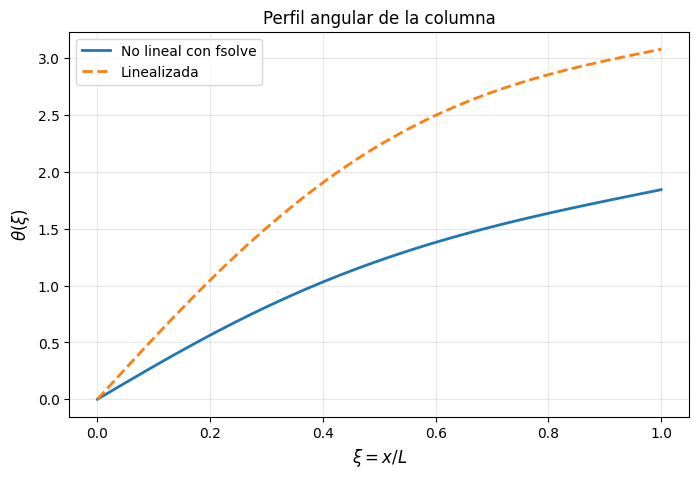

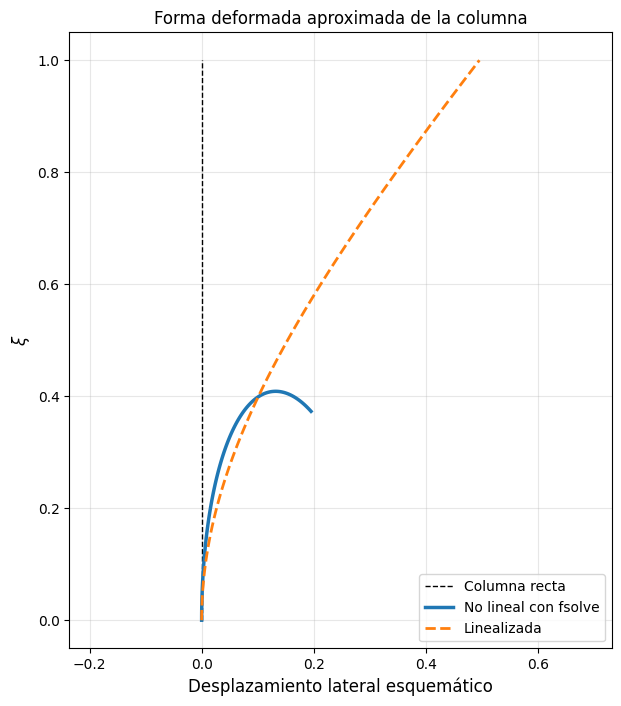

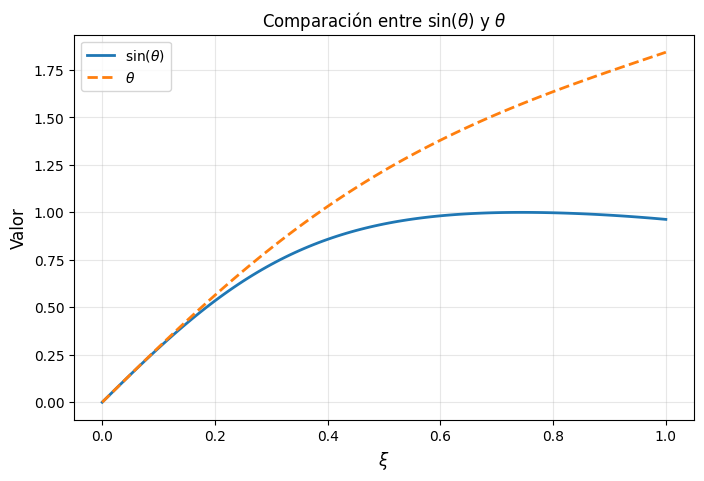

Diferencia máxima entre solución no lineal y linealizada = 1.2358e+00

Interpretación:
- La solución no lineal se obtiene resolviendo directamente el sistema F(theta)=0.
- La linealización sin(theta)≈theta puede ser razonable para ángulos muy pequeños.
- Cuando los ángulos crecen, la solución no lineal es más fiel al fenómeno físico.
- Este ejemplo muestra cómo combinar diferencias finitas con fsolve.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ============================================================
# 1. PARÁMETROS DEL PROBLEMA
# ============================================================
N = 120                    # número de subintervalos
h = 1.0 / N
xi = np.linspace(0.0, 1.0, N + 1)

# Parámetro adimensional del problema:
# lambda = w L^3 / (EI)
lam = 6.0

# ============================================================
# 2. FUNCIÓN QUE DEFINE EL SISTEMA NO LINEAL F(theta)=0
# ============================================================
def sistema_no_lineal(theta):
    F = np.zeros_like(theta)

    # BC en la base: theta(0)=0
    F[0] = theta[0]

    # Ecuaciones interiores
    for i in range(1, N):
        F[i] = (theta[i-1] - 2.0*theta[i] + theta[i+1]) / h**2 \
               + lam * (1.0 - xi[i]) * np.sin(theta[i])

    # BC en la punta: theta'(1)=1
    F[N] = (theta[N] - theta[N-1]) / h - 1.0

    return F

# ============================================================
# 3. VECTOR INICIAL
# ============================================================
# Es importante dar una aproximación inicial razonable a fsolve.
# Elegimos una forma suave creciente.
theta_ini = 0.8 * xi**2

# ============================================================
# 4. SOLUCIÓN CON FSOLVE
# ============================================================
theta_sol, info, ier, msg = fsolve(sistema_no_lineal, theta_ini, full_output=True)

print("="*72)
print("COLUMNA BAJO SU PROPIO PESO - PROBLEMA NO LINEAL")
print("="*72)
print(f"Número de subintervalos N = {N}")
print(f"Valor fijado del parámetro lambda = {lam:.4f}")
print(f"Indicador de convergencia de fsolve (ier) = {ier}")
print(f"Mensaje de fsolve: {msg}")
print("="*72)

# Residuo máximo
residuo = np.max(np.abs(sistema_no_lineal(theta_sol)))
print(f"Máximo residuo |F(theta)| = {residuo:.3e}")

# ============================================================
# 5. RECONSTRUCCIÓN ESQUEMÁTICA DE LA FORMA DE LA COLUMNA
# ============================================================
# Para visualizar la forma, usamos:
# dx/dxi ~ sin(theta),    dy/dxi ~ cos(theta)
# y luego integramos numéricamente.
x_def = np.zeros_like(xi)
y_def = np.zeros_like(xi)

for i in range(1, len(xi)):
    dx1 = np.sin(theta_sol[i-1])
    dx2 = np.sin(theta_sol[i])
    dy1 = np.cos(theta_sol[i-1])
    dy2 = np.cos(theta_sol[i])

    x_def[i] = x_def[i-1] + 0.5 * (dx1 + dx2) * (xi[i] - xi[i-1])
    y_def[i] = y_def[i-1] + 0.5 * (dy1 + dy2) * (xi[i] - xi[i-1])

# Reescalamos lateralmente solo para hacer visible la figura
escala = 0.25
x_plot = escala * x_def

# ============================================================
# 6. SOLUCIÓN LINEALIZADA PARA COMPARAR
# ============================================================
A = np.zeros((N + 1, N + 1))
b = np.zeros(N + 1)

A[0, 0] = 1.0
b[0] = 0.0

for i in range(1, N):
    A[i, i-1] = 1.0
    A[i, i]   = -2.0 + h**2 * lam * (1.0 - xi[i])
    A[i, i+1] = 1.0
    b[i] = 0.0

A[N, N-1] = -1.0
A[N, N] = 1.0
b[N] = h

theta_lin = np.linalg.solve(A, b)

# forma linealizada
x_lin = np.zeros_like(xi)
y_lin = xi.copy()
for i in range(1, len(xi)):
    x_lin[i] = x_lin[i-1] + 0.5*(theta_lin[i-1] + theta_lin[i])*(xi[i]-xi[i-1])
x_lin = escala * x_lin

# ============================================================
# 7. GRÁFICAS
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(xi, theta_sol, linewidth=2, label="No lineal con fsolve")
plt.plot(xi, theta_lin, "--", linewidth=2, label="Linealizada")
plt.xlabel(r"$\xi = x/L$", fontsize=12)
plt.ylabel(r"$\theta(\xi)$", fontsize=12)
plt.title("Perfil angular de la columna")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7,8))
plt.plot([0,0], [0,1], "k--", linewidth=1, label="Columna recta")
plt.plot(x_plot, y_def, linewidth=2.5, label="No lineal con fsolve")
plt.plot(x_lin, y_lin, "--", linewidth=2, label="Linealizada")
plt.xlabel("Desplazamiento lateral esquemático", fontsize=12)
plt.ylabel(r"$\xi$", fontsize=12)
plt.title("Forma deformada aproximada de la columna")
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis("equal")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(xi, np.sin(theta_sol), linewidth=2, label=r"$\sin(\theta)$")
plt.plot(xi, theta_sol, "--", linewidth=2, label=r"$\theta$")
plt.xlabel(r"$\xi$", fontsize=12)
plt.ylabel("Valor", fontsize=12)
plt.title(r"Comparación entre $\sin(\theta)$ y $\theta$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# 8. COMENTARIOS NUMÉRICOS
# ============================================================
dif = np.max(np.abs(theta_sol - theta_lin))
print(f"Diferencia máxima entre solución no lineal y linealizada = {dif:.4e}")

print("\nInterpretación:")
print("- La solución no lineal se obtiene resolviendo directamente el sistema F(theta)=0.")
print("- La linealización sin(theta)≈theta puede ser razonable para ángulos muy pequeños.")
print("- Cuando los ángulos crecen, la solución no lineal es más fiel al fenómeno físico.")
print("- Este ejemplo muestra cómo combinar diferencias finitas con fsolve.")


## 7. Comentarios finales para los estudiantes

Este ejemplo muestra una idea importante:

> **Diferencias finitas no solo sirve para problemas lineales.**  
> También puede usarse para transformar una ecuación diferencial no lineal en un sistema algebraico no lineal.

Luego ese sistema puede resolverse con herramientas como `fsolve`.

## 8. Ventajas y dificultad del modelo no lineal

### Ventaja
Se conserva la forma física original del problema:

$\\theta'' + \lambda(1-\xi)\sin\theta = 0$

sin reemplazar $\sin\theta$ por $\theta$.

### Dificultad
Ahora el sistema es no lineal, así que:

- se necesita un vector inicial,
- la convergencia puede depender de esa estimación inicial,
- y el problema es más exigente numéricamente.

## 9. Posibles extensiones

1. Cambiar el valor de $\lambda$ y ver cómo cambia la forma de la columna.
2. Probar distintos vectores iniciales en `fsolve`.
3. Refinar la malla.
4. Comparar el problema no lineal con el linealizado.
5. Reemplazar la condición $\theta'(1)=1$ por otra condición de escala.

